In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

In [3]:
import os
from pathlib import Path

data_file = Path('test_FD001.txt')
if not data_file.exists():
    candidates = list(Path.cwd().rglob('test_FD001.txt'))
    if candidates:
        data_file = candidates[0]
    else:
        raise FileNotFoundError(
            f"{data_file} not found in {Path.cwd()}. "
            "Place the file in the notebook directory or update the path."
        )

train = pd.read_csv(data_file, sep=r'\s+', header=None, names=col_names)
print(f"Loaded data from {data_file}")

Loaded data from c:\Users\user\Mechanical Engineering Data Science Projects\CMaps\test_FD001.txt


In [4]:
max_cycle = train.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_nr', 'max_cycles']

In [5]:
train = train.merge(max_cycle, on=['unit_nr'], how='left')

In [6]:
train['RUL'] = train['max_cycles'] - train['time_cycles']
train.drop('max_cycles', axis=1, inplace=True)
train.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,30
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,29
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,28
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,27
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,26


In [7]:
stats = train.describe().T
constant_sensors = stats[stats['std'] == 0].index.tolist()
train.drop(labels=constant_sensors, axis=1, inplace=True)

In [8]:
if 'setting_3' in train.columns:
    train.drop(['setting_3'], axis=1, inplace=True)

print(f"Dropped constant columns: {constant_sensors}")

Dropped constant columns: ['setting_3', 's_18', 's_19']


In [9]:
X = train.drop(['unit_nr', 'time_cycles', 'RUL'], axis=1)
y = train['RUL']

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
model.fit(X_scaled, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [12]:
y_pred = model.predict(X_scaled)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Training RMSE: {rmse:.2f} cycles")

Training RMSE: 28.86 cycles


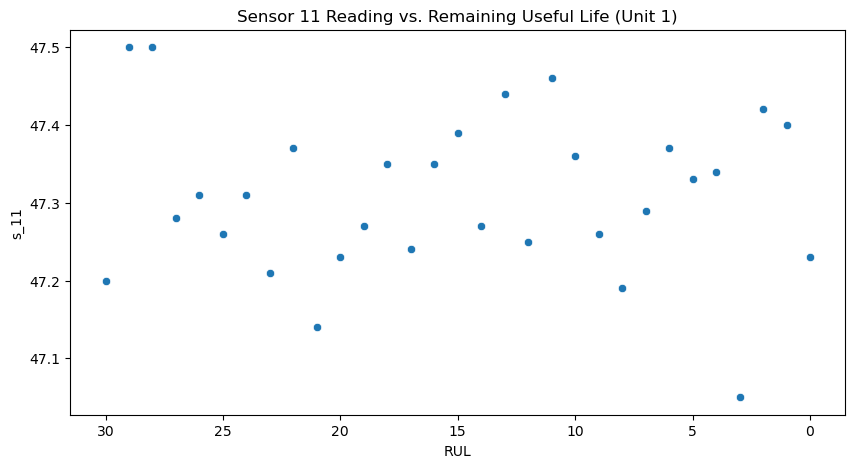

In [13]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=train[train['unit_nr']==1], x='RUL', y='s_11')
plt.title('Sensor 11 Reading vs. Remaining Useful Life (Unit 1)')
plt.gca().invert_xaxis() # Show RUL counting down to zero
plt.show()

In [14]:
def predict_maintenance(sensor_data):
    scaled_input = scaler.transform(sensor_data)
    prediction = model.predict(scaled_input)
    return prediction[0]

In [15]:
sample_engine_data = X.iloc[0:1]
print(f"Predicted RUL: {predict_maintenance(sample_engine_data):.1f} cycles")

Predicted RUL: 59.5 cycles
